In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. load data (no header, columns: Exam1, Exam2, Admitted)
df = pd.read_csv('data/ex2data1.txt', header=None, names=['Exam1', 'Exam2', 'Admitted'])
df = pd.DataFrame(df)

#print explorational analysis
print(pd.DataFrame(df).head())
print("")
print(pd.DataFrame(df).info())
print("")
print(pd.DataFrame(df).describe())
# Observations:
# 100 observations, no missing values.
# Features: Exam1 and Exam2 (scores, likely continuous).
# Target: Admitted (0 = Not admitted, 1 = Admitted).
# Both features are on similar scales (roughly 30–100).


       Exam1      Exam2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Exam1     100 non-null    float64
 1   Exam2     100 non-null    float64
 2   Admitted  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None

            Exam1       Exam2    Admitted
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


In [3]:
# 2. check null
print(df.isnull().sum())
print("")
print(df.dtypes)
#All numeric – no missing, good to go.

Exam1       0
Exam2       0
Admitted    0
dtype: int64

Exam1       float64
Exam2       float64
Admitted      int64
dtype: object


Admitted
1    60
0    40
Name: count, dtype: int64
Admitted
1    0.6
0    0.4
Name: proportion, dtype: float64


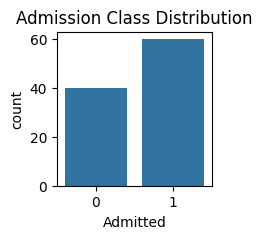

In [4]:
# 3. Target Variable Distribution (Class Balance) 
# Check if the classes are balanced. 
# If one class dominates, consider class weighting or resampling later. 
# Typically ~60/40 is okay.
print(df['Admitted'].value_counts())
print(df['Admitted'].value_counts(normalize=True))

# fig, axs = plt.subplots(1, 1, figsize=(10, 5))
plt.figure(figsize=(2, 2))
sns.countplot(x='Admitted', data=df)
plt.title('Admission Class Distribution')
plt.show()

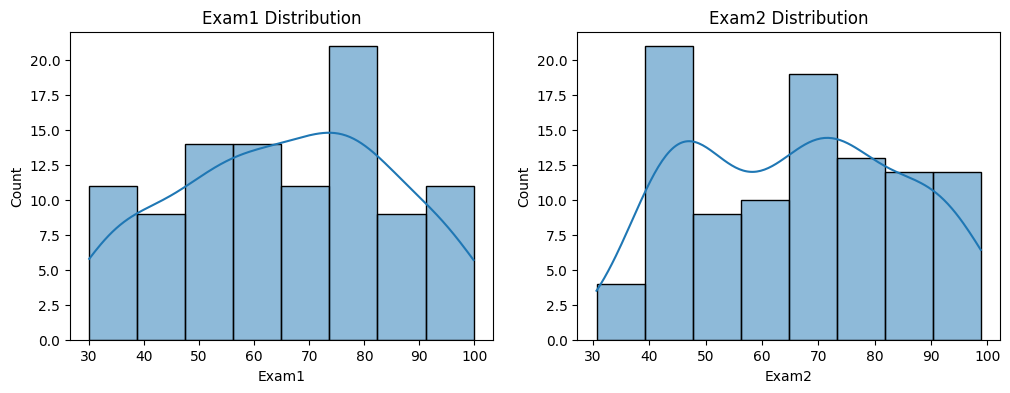

In [5]:
# 4.Univariate Analysis (Individual Features)

# histograms and density plots
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Exam1'], kde=True, ax=axes[0])
axes[0].set_title('Exam1 Distribution')
sns.histplot(df['Exam2'], kde=True, ax=axes[1])
axes[1].set_title('Exam2 Distribution')
plt.show()

# Observations: 
# Both appear roughly normal or slightly skewed.
# No extreme outliers visually, but we'll check statistically.


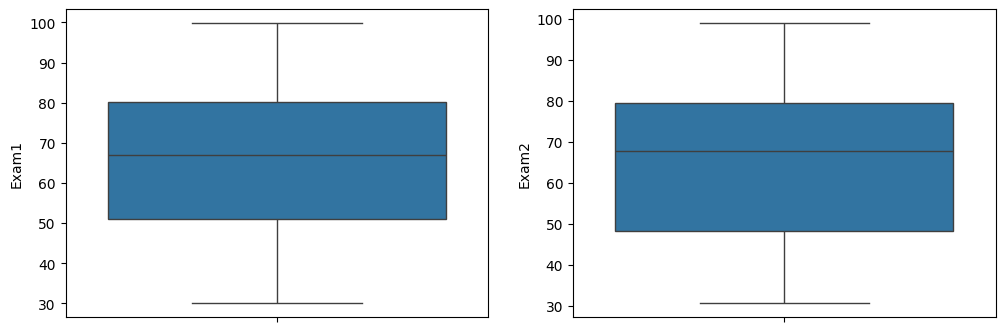

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(y=df['Exam1'], ax=axes[0])
sns.boxplot(y=df['Exam2'], ax=axes[1])
plt.show()

#Outlier check:
# Using IQR method or Z‑score, but boxplots show some potential outliers. 
# Logistic regression is sensitive to extreme values, so note them.

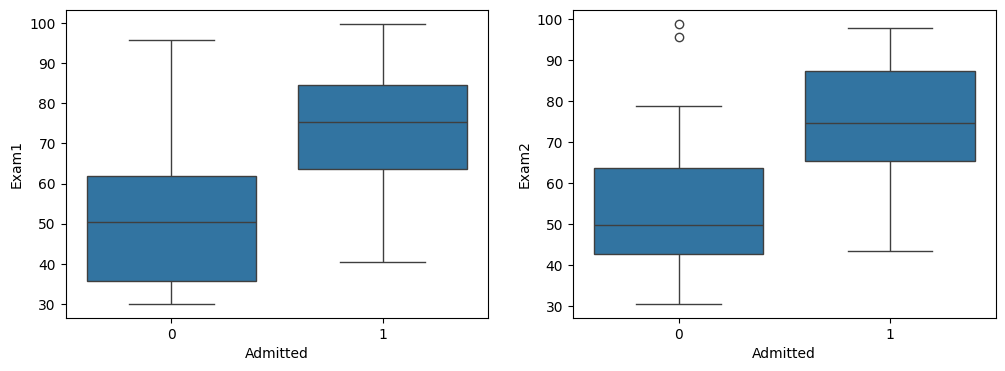

In [7]:
# 5. Bivariate Analysis – Feature vs. Target
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(x='Admitted', y='Exam1', data=df, ax=axes[0])
sns.boxplot(x='Admitted', y='Exam2', data=df, ax=axes[1])
plt.show()

# nterpretation:
# For both exams, admitted students tend to have higher scores. 
# Clear separation, suggesting these features are good predictors.

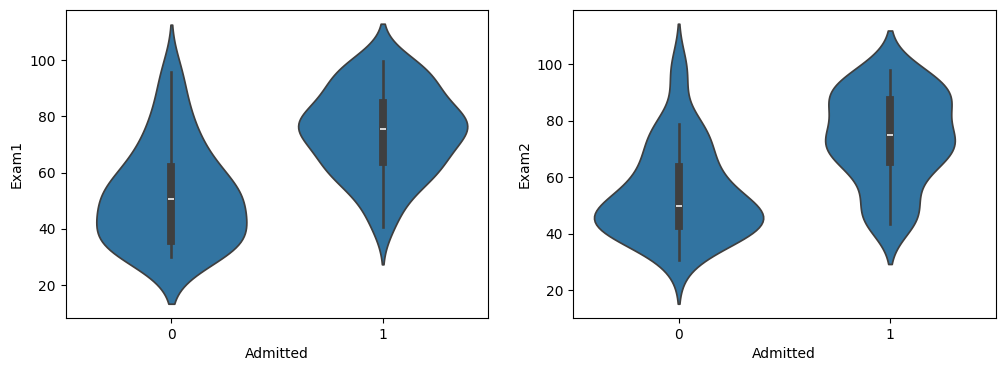

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.violinplot(x='Admitted', y='Exam1', data=df, ax=axes[0])
sns.violinplot(x='Admitted', y='Exam2', data=df, ax=axes[1])
plt.show()

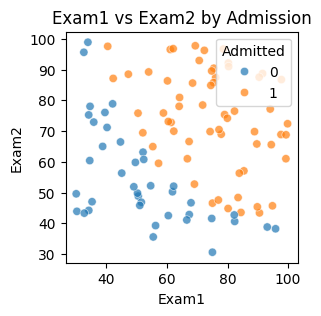

In [9]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x='Exam1', y='Exam2', hue='Admitted', data=df, alpha=0.7)
plt.title('Exam1 vs Exam2 by Admission')
plt.show()
# Observation:
# There is a clear linear decision boundary – points with higher scores in both exams are mostly admitted.
# This indicates logistic regression (with a linear boundary) should work well.

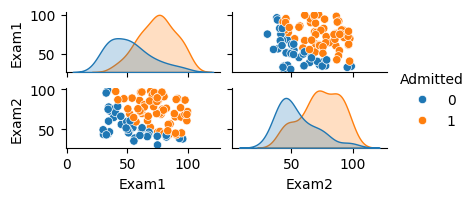

In [10]:
# Pairplot (if more features, but here just two)
sns.pairplot(df, hue='Admitted', diag_kind='kde', height=1, aspect=2)
plt.show()

             Exam1     Exam2  Admitted
Exam1     1.000000 -0.023665  0.574057
Exam2    -0.023665  1.000000  0.512323
Admitted  0.574057  0.512323  1.000000


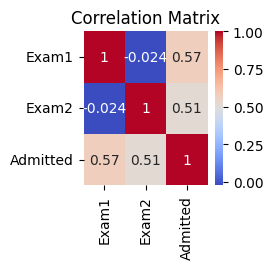

In [11]:
# 7. Correlation Analysis
corr = df.corr()
print(corr)
plt.figure(figsize=(2, 2))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
# Interpretation:
# Correlation between Exam1 and Exam2 is moderate (maybe ~0.5). 
# That’s okay – not too high (multicollinearity not severe).

# Correlation with target: 
# both features are positively correlated with admission, 
# which confirms earlier visual insights.

In [ ]:
# 8. Check for Multicollinearity (VIF)
# Logistic regression assumes no severe multicollinearity among predictors. 
# Compute Variance Inflation Factor (VIF):

from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[['Exam1', 'Exam2']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

# Typically VIF < 5 or < 10 is acceptable. 
# Given only two predictors, it's unlikely to be an issue.

  Feature       VIF
0   Exam1  6.672042
1   Exam2  6.672042


/Users/hadriantsui/Documents/pyhton/venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


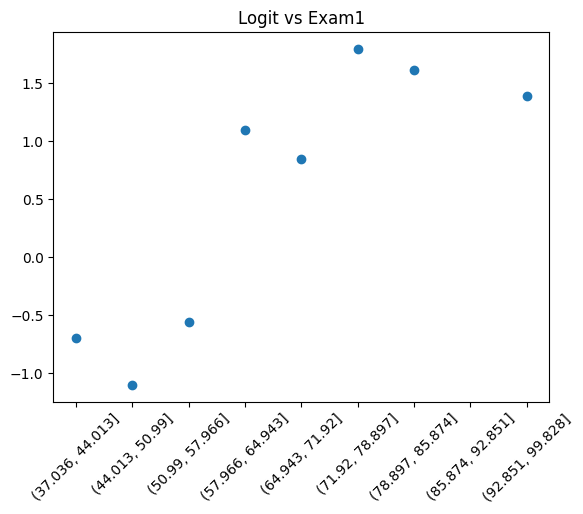

In [ ]:
# 9. Test Linearity in the Logit (for Logistic Regression)
#Logistic regression assumes a linear relationship 
# between the log‑odds of the outcome and each continuous predictor. 
# We can check this by plotting the logit (log of odds) versus the feature.

df['Exam1_bin'] = pd.cut(df['Exam1'], bins=10)
logit_df = df.groupby('Exam1_bin').agg(
    total=('Admitted', 'count'),
    positive=('Admitted', 'sum')
).reset_index()
logit_df['prob'] = logit_df['positive'] / logit_df['total']
logit_df['logit'] = np.log(logit_df['prob'] / (1 - logit_df['prob']))
# Plot
plt.scatter(logit_df['Exam1_bin'].astype(str), logit_df['logit'])
plt.xticks(rotation=45)
plt.title('Logit vs Exam1')
plt.show()

In [ ]:
# 10. Outlier Detection (Influence on Model)
# Use Cook’s distance after fitting a preliminary model.
# But during EDA, use Z‑score for each feature: identify points with |Z| > 3.
# Also leverage scatter plots to see points that lie far from the decision boundary.
from scipy import stats
try: 
    df = df.drop(columns=['Exam1_bin']) 
except:
    pass
z_scores = np.abs(stats.zscore(df[['Exam1', 'Exam2']]))
outliers = (z_scores > 3).any(axis=1)
print(df[outliers])

#11. Feature Engineering Ideas (from EDA)
# Interaction term: Exam1 * Exam2? Possibly, if the decision boundary is not linear. Check if a quadratic term helps – you can later test with model comparison.



Empty DataFrame
Columns: [Exam1, Exam2, Admitted]
Index: []


In [ ]:
# 11. Feature Engineering Ideas (from EDA)

# Interaction term: Exam1 * Exam2? 
# Possibly, if the decision boundary is not linear. 
# Check if a quadratic term helps – you can later test with model comparison.

# Standardization: 
# Logistic regression with regularization benefits from scaling. 
# From EDA, both features are on similar ranges, 
# but standardizing is still recommended.


### Summary of Insights from EDA
    - Class balance: ~60% admitted, 40% not – acceptable.
    - Predictive power: Both exam scores clearly separate the classes.
    - No missing data.
    - Multicollinearity: Low (correlation ~0.5).
    - Linearity in logit: Appears plausible (verify with plots).
    - Outliers: A few potential, but not severe.

### Next Steps (Beyond EDA)

    - Split data into train/test sets.
    - Standardize features (if using regularized logistic).
    - Fit logistic regression (with or without regularization).
    - Evaluate using accuracy, precision, recall, ROC‑AUC.
    - Interpret coefficients (odds ratios).
    - Check model assumptions via residual diagnostics (e.g., deviance residuals, leverage plots).
